# 09 — Paper Figures

Final publication-ready exports: one headline table + four figures, each saved as both PDF (vector, for the paper) and PNG (raster, for preview / Slack).

Consumes the production-sweep outputs (no prefix). Inputs:
- `results/predictions/pooled_allLeads.nc`
- `results/metrics/metrics_allLeads.csv`
- `results/logs/feature_status.csv`

Outputs:
- `results/figures/09_paper/headline_table.csv`  and  `headline_table.tex`
- `results/figures/09_paper/fig01_acc_vs_lead.{pdf,png}`
- `results/figures/09_paper/fig02_msss_bars.{pdf,png}`
- `results/figures/09_paper/fig03_spatial_skill.{pdf,png}`
- `results/figures/09_paper/fig04_feature_importance.{pdf,png}`

Typography is set once at the top via `rcParams`, so every figure inherits the same fonts / sizes. Editable PDF text (`pdf.fonttype=42`) so labels can be tweaked in Illustrator if needed.

> **Winter-training variant.** Same notebook body as `09_paper_figures.ipynb`, re-pointed at the **winter-only training** sweep. Reads from the corresponding subfolder under `results/` and writes figures under `results/figures/...`. The `EXPERIMENT_NAME` constant in the setup cell controls the suffix appended to every figure title.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from droughtmodel.utils import RESULTS_DIR
from droughtmodel import data as ddata
from droughtmodel import features as dfeat

# -------------------------------------------------------------------
# Paper-grade typography. Applied to every figure below.
# -------------------------------------------------------------------
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'axes.linewidth':    0.8,
    'legend.fontsize':   8.5,
    'legend.frameon':    True,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'figure.dpi':        100,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})
sns.set_palette('tab10')

PAPER_DIR = RESULTS_DIR / 'figures' / '10_winter-training' / '09_paper'
PAPER_DIR.mkdir(parents=True, exist_ok=True)
# Identifier appended to every figure title so default / winter / pruned-winter
# variants are visually distinguishable when laid out side-by-side. The duplication
# script swaps the value for the _winter and _pruned-winter notebooks.
EXPERIMENT_NAME = 'winter-training'
def _ttl(text: str) -> str:
    return f'{text}  ·  experiment: {EXPERIMENT_NAME}'


def save_paper(fig, name):
    """Save a figure as both PDF (vector) and PNG (raster) at 300 dpi."""
    fig.savefig(PAPER_DIR / f'{name}.pdf')
    fig.savefig(PAPER_DIR / f'{name}.png')
    print(f'  -> {(PAPER_DIR / name).relative_to(ROOT)}.{{pdf,png}}')

ds_preds   = xr.open_dataset(RESULTS_DIR / 'winter-training' / 'predictions' / 'pooled_allLeads.nc')
metrics_df = pd.read_csv(RESULTS_DIR / 'winter-training' / 'metrics' / 'metrics_allLeads.csv')
feat       = pd.read_csv(RESULTS_DIR / 'winter-training' / 'logs' / 'feature_status.csv')

MODEL_ORDER = ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
BASELINE_NAMES = {'climatology', 'persistence', 'ar'}
models_present = [m for m in MODEL_ORDER if m in metrics_df['model'].unique()]
leads = sorted(metrics_df['lead'].unique())

# Pooled-only slice for Figures 1-3 and Table 1. Per-fold rows are used
# separately by Figure 5 (stability) via a direct query on `metrics_df`.
winter = metrics_df.query("evaluation_window == 'winter_only' and fold == 'pooled'")

ml_models = [m for m in models_present if m not in BASELINE_NAMES]
best_ml = (winter
    .query("model in @ml_models and metric == 'msss_vs_climatology'")
    .groupby('model')['value'].mean().idxmax())

print(f'Production data loaded:  {len(metrics_df)} metric rows, {len(feat)} feature-status rows')
n_per_fold = (metrics_df['fold'] != 'pooled').sum()
if n_per_fold:
    print(f'  (incl. {n_per_fold} per-fold rows for the stability figure)')
print(f'Models:                  {models_present}')
print(f'Leads:                   {leads}')
print(f'Best ML model (by mean MSSS-vs-clim): {best_ml!r}')
print(f'Output dir:              {PAPER_DIR.relative_to(ROOT)}')

Production data loaded:  1944 metric rows, 7197 feature-status rows
  (incl. 1620 per-fold rows for the stability figure)
Models:                  ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
Leads:                   [np.int64(1), np.int64(3), np.int64(6)]
Best ML model (by mean MSSS-vs-clim): 'lasso'
Output dir:              results/figures/10_winter-training/09_paper


## Table 1 — Headline skill (LaTeX-ready)

Model x lead grid for the six headline metrics. Winter-only pool. `*` marks 95 % bootstrap CI excluding zero (significance, higher-is-better metrics only).

In [2]:
HIGHER_IS_BETTER = {'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence'}
HEADLINE_METRICS = ['mae', 'rmse', 'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence']
METRIC_LABELS = {
    'mae': 'MAE', 'rmse': 'RMSE', 'pearson_r': 'r',
    'acc': 'ACC', 'msss_vs_climatology': 'MSSS\\textsubscript{clim}',
    'msss_vs_persistence': 'MSSS\\textsubscript{pers}',
}

def _sig(row):
    if row['metric'] not in HIGHER_IS_BETTER: return False
    if pd.isna(row['ci_lower']) or pd.isna(row['ci_upper']): return False
    return bool(row['ci_lower'] > 0 or row['ci_upper'] < 0)

def _fmt(row):
    v = row['value']
    if pd.isna(v): return '---'
    return f'{v:.2f}' + ('*' if _sig(row) else '')

tab = winter.copy()
tab['fmt'] = tab.apply(_fmt, axis=1)
table = (tab.pivot(index=['model', 'lead'], columns='metric', values='fmt')
            .loc[[(m, L) for m in models_present for L in leads]]
            [HEADLINE_METRICS])
table.columns.name = None

table.to_csv(PAPER_DIR / 'headline_table.csv')

latex_table = table.rename(columns=METRIC_LABELS).to_latex(
    escape=False, na_rep='---',
    caption='Headline skill on the pooled winter target months (Nov-Feb, 2000-2024). '
            '$^*$ denotes a 95\\,\\% block-bootstrap CI excluding zero '
            '(higher-is-better metrics only).',
    label='tab:headline_skill',
    column_format='ll' + 'r' * len(HEADLINE_METRICS),
)
(PAPER_DIR / 'headline_table.tex').write_text(latex_table)
print('  -> headline_table.{csv,tex}')

table

  -> headline_table.{csv,tex}


mae  rmse pearson_r    acc msss_vs_climatology  \
model       lead                                                    
climatology 1     0.83  0.99    -0.12*    ---                0.00   
            3     0.83  1.00    -0.10*    ---                0.00   
            6     0.87  1.03    -0.20*    ---                0.00   
persistence 1     0.55  0.71     0.72*  0.72*               0.49*   
            3     1.08  1.32      0.02   0.02              -0.74*   
            6     1.00  1.27      0.14   0.15              -0.50*   
ar          1     0.51  0.62     0.77*  0.77*               0.61*   
            3     0.82  0.99     -0.04   0.10               0.03*   
            6     0.85  1.01      0.04  0.28*               0.04*   
ols         1     0.45  0.55     0.81*  0.81*               0.69*   
            3     0.89  1.07     -0.13  -0.10              -0.15*   
            6     1.20  1.45     -0.01   0.04              -0.97*   
ridge       1     0.44  0.55     0.82*  0.82*               0.70*   
            3     0.86  1.04     -0.14  -0.10              -0.08*   
            6     1.02  1.23     -0.03   0.02              -0.42*   
lasso       1     0.44  0.54     0.82*  0.82*               0.70*   
            3     0.82  0.99     -0.07   0.04                0.02   
            6     0.85  1.02     0.20*  0.29*               0.03*   
elasticnet  1     0.45  0.54     0.82*  0.82*               0.70*   
            3     0.82  0.99     -0.07   0.03                0.02   
            6     0.85  1.02     0.20*  0.29*               0.03*   
rf          1     0.52  0.63     0.75*  0.76*               0.60*   
            3     0.84  1.02      0.08   0.09               -0.04   
            6     0.85  1.02      0.00   0.11                0.04   
xgboost     1     0.50  0.61     0.77*  0.78*               0.63*   
            3     0.82  0.99      0.11  0.15*                0.02   
            6     0.91  1.12     -0.09  -0.04               -0.17   

                 msss_vs_persistence  
model       lead                      
climatology 1                 -0.96*  
            3                  0.43*  
            6                  0.33*  
persistence 1                   0.00  
            3                   0.00  
            6                   0.00  
ar          1                  0.23*  
            3                  0.44*  
            6                  0.36*  
ols         1                  0.39*  
            3                  0.34*  
            6                  -0.32  
ridge       1                  0.41*  
            3                  0.38*  
            6                   0.05  
lasso       1                  0.42*  
            3                  0.44*  
            6                  0.36*  
elasticnet  1                  0.41*  
            3                  0.44*  
            6                  0.36*  
rf          1                  0.21*  
            3                  0.40*  
            6                  0.36*  
xgboost     1                  0.27*  
            3                  0.44*  
            6                   0.22

## Figure 1 — Skill vs lead

ACC and MSSS-vs-climatology as functions of forecast lead. Each model is one line; error bars are the 95 % block-bootstrap CI. Climatology is omitted from the ACC panel (zero-variance forecast then ACC undefined).

  -> results/figures/10_winter-training/09_paper/fig01_acc_vs_lead.{pdf,png}


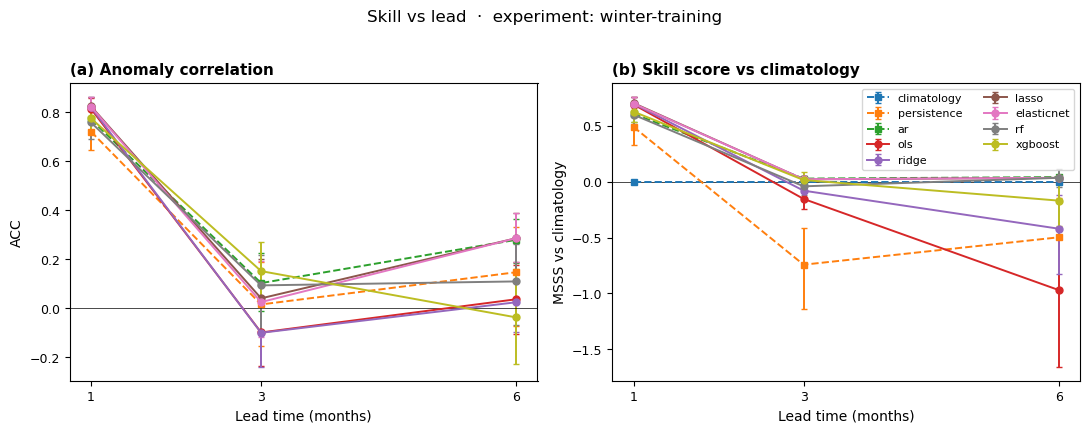

In [3]:
colors = dict(zip(MODEL_ORDER, sns.color_palette('tab10', n_colors=len(MODEL_ORDER))))
linestyles = {**{m: '--' for m in BASELINE_NAMES}, **{m: '-' for m in ml_models}}
markers = {**{m: 's' for m in BASELINE_NAMES}, **{m: 'o' for m in ml_models}}

def _line(ax, metric_name, ylabel, drop_models=()):
    sub = winter[winter['metric'] == metric_name]
    for mdl in models_present:
        if mdl in drop_models:
            continue
        s = sub[sub['model'] == mdl].sort_values('lead')
        if s['value'].isna().all():
            continue
        yerr_lo = s['value'].values - s['ci_lower'].values
        yerr_hi = s['ci_upper'].values - s['value'].values
        ax.errorbar(
            s['lead'], s['value'], yerr=[yerr_lo, yerr_hi],
            marker=markers.get(mdl, 'o'), markersize=5,
            capsize=2.5, linewidth=1.4, linestyle=linestyles.get(mdl, '-'),
            color=colors.get(mdl, None), label=mdl,
        )
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(leads)
    ax.set_xlabel('Lead time (months)')
    ax.set_ylabel(ylabel)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
_line(axes[0], 'acc', 'ACC', drop_models={'climatology'})
_line(axes[1], 'msss_vs_climatology', 'MSSS vs climatology')
axes[0].set_title('(a) Anomaly correlation', loc='left', fontweight='bold', fontsize=11)
fig.suptitle(_ttl('Skill vs lead'), y=1.02)
axes[1].set_title('(b) Skill score vs climatology', loc='left', fontweight='bold', fontsize=11)
axes[1].legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
save_paper(fig, 'fig01_acc_vs_lead')
plt.show()

## Figure 2 — Skill scores by model

Bar chart of MSSS-vs-climatology and MSSS-vs-persistence per (model, lead) on the winter pool. Bars above zero beat the reference. Error bars are 95 % block-bootstrap CIs.

  -> results/figures/10_winter-training/09_paper/fig02_msss_bars.{pdf,png}


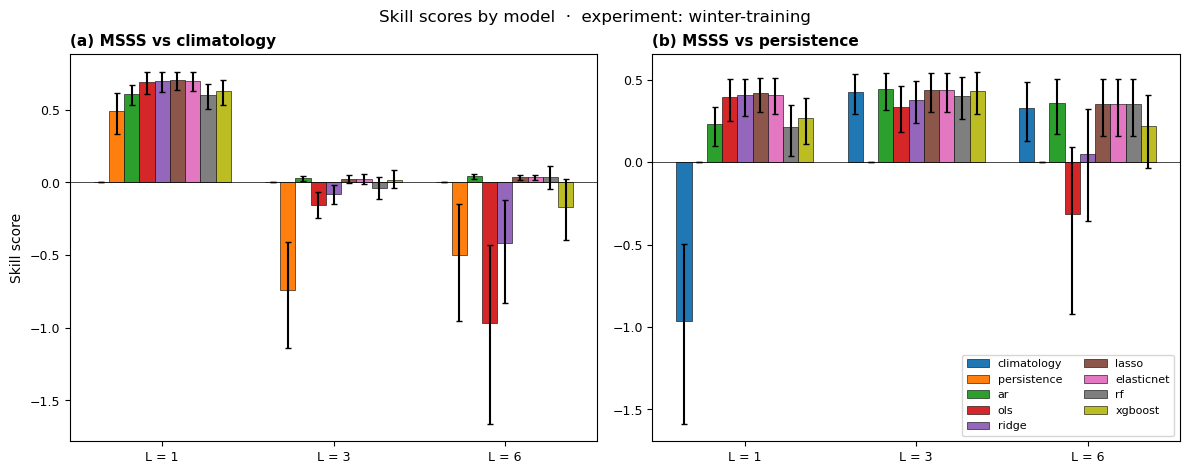

In [4]:
def _bars(ax, metric_name, title):
    sub = winter[winter['metric'] == metric_name]
    n = len(models_present)
    width = 0.8 / n
    x = np.arange(len(leads))
    for i, mdl in enumerate(models_present):
        s = sub[sub['model'] == mdl].set_index('lead').reindex(leads)
        ye_lo = s['value'].values - s['ci_lower'].values
        ye_hi = s['ci_upper'].values - s['value'].values
        ax.bar(
            x + (i - n / 2 + 0.5) * width, s['value'].values,
            yerr=np.vstack([ye_lo, ye_hi]),
            capsize=2.0, width=width,
            edgecolor='black', linewidth=0.4,
            color=colors.get(mdl, None), label=mdl,
        )
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f'L = {L}' for L in leads])
    ax.set_title(title, loc='left', fontweight='bold', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
_bars(axes[0], 'msss_vs_climatology', '(a) MSSS vs climatology')
_bars(axes[1], 'msss_vs_persistence', '(b) MSSS vs persistence')
axes[0].set_ylabel('Skill score')
axes[1].legend(loc='lower right', ncol=2, fontsize=8)
plt.tight_layout()
fig.suptitle(_ttl('Skill scores by model'), y=1.02)
save_paper(fig, 'fig02_msss_bars')
plt.show()

## Figure 3 — Spatial skill story

Per-cell ACC over the winter pool. Three rows compare the strongest baseline at each lead, the best ML model overall (selected dynamically — see setup cell output), and their difference. The Delta-ACC row is the cleanest 'where does ML add value?' diagnostic — red regions are where the ML model beats the baseline.

/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_74178/2290472724.py:11: RuntimeWarning: Mean of empty slice
  num = np.nanmean((pa - np.nanmean(pa, axis=0)) * (ta - np.nanmean(ta, axis=0)), axis=0)
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  -> results/figures/10_winter-training/09_paper/fig03_spatial_skill.{pdf,png}


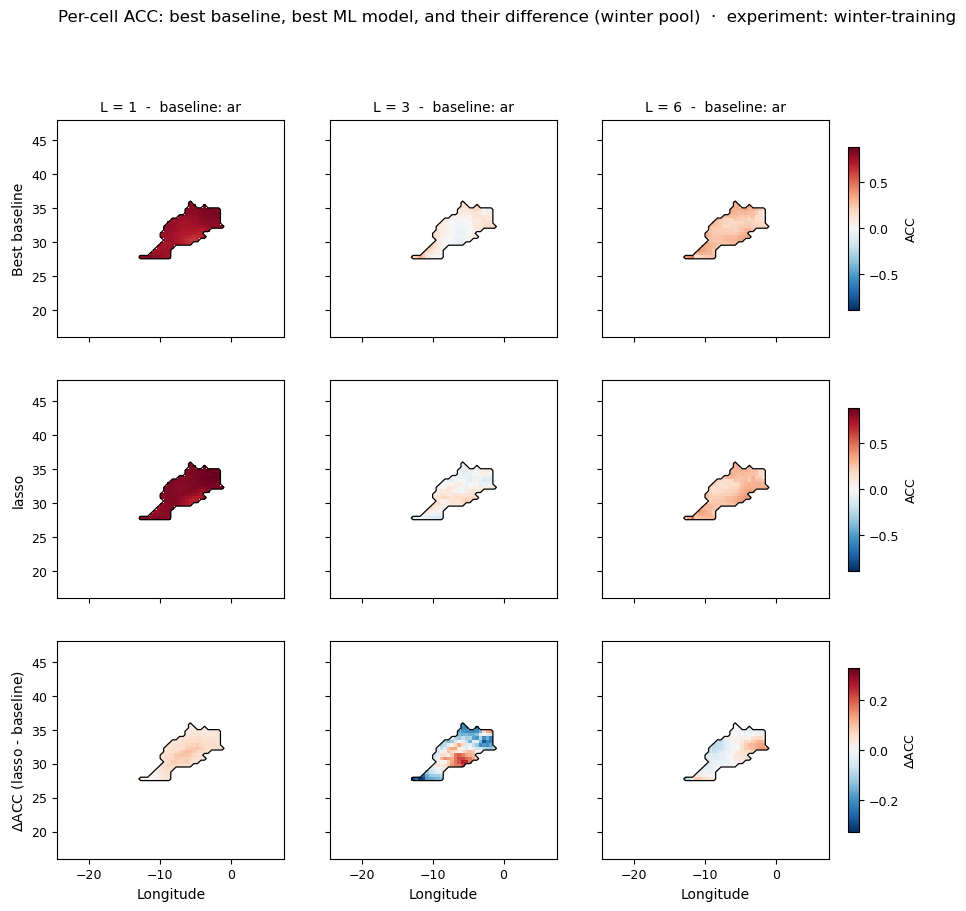


Morocco-mean Delta-ACC (ML - baseline):
  L = 1  baseline=ar           mean = +0.054, %cells positive = 4%
  L = 3  baseline=ar           mean = -0.032, %cells positive = 2%
  L = 6  baseline=ar           mean = +0.006, %cells positive = 2%


In [5]:
data_cfg = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_cfg = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
raw_datasets = ddata.load_all(data_cfg)
template = dfeat.gather_predictor('spei3', raw_datasets)
morocco_mask = dfeat.load_region_mask(feat_cfg['region_mask']['path'], template, name='morocco')
lat, lon = morocco_mask['lat'], morocco_mask['lon']

def per_cell_acc(pred, truth, clim, winter_mask, mask):
    yp, yt, yc = pred[winter_mask], truth[winter_mask], clim[winter_mask]
    pa, ta = yp - yc, yt - yc
    num = np.nanmean((pa - np.nanmean(pa, axis=0)) * (ta - np.nanmean(ta, axis=0)), axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        a = num / (np.nanstd(pa, axis=0) * np.nanstd(ta, axis=0))
    a[~mask.values] = np.nan
    return a

time_idx = pd.DatetimeIndex(ds_preds['time'].values)
winter_mask = np.isin(time_idx.month, [11, 12, 1, 2])

best_baseline_per_lead = {}
for L in leads:
    vals = (winter
        .query("model in @BASELINE_NAMES and model != 'climatology' and lead == @L and metric == 'msss_vs_climatology'")
        .set_index('model')['value'])
    best_baseline_per_lead[L] = vals.idxmax() if not vals.empty else 'persistence'

panels = {}
for L in leads:
    base = best_baseline_per_lead[L]
    truth = ds_preds['truth'].sel(lead=L).values
    clim = ds_preds['pred_climatology'].sel(lead=L).values
    p_base = ds_preds[f'pred_{base}'].sel(lead=L).values
    p_ml = ds_preds[f'pred_{best_ml}'].sel(lead=L).values
    acc_base = per_cell_acc(p_base, truth, clim, winter_mask, morocco_mask)
    acc_ml = per_cell_acc(p_ml, truth, clim, winter_mask, morocco_mask)
    panels[L] = {'base': acc_base, 'ml': acc_ml, 'diff': acc_ml - acc_base, 'base_name': base}

vmax_acc = float(np.nanmax(np.abs([panels[L][k] for L in leads for k in ('base', 'ml')]))) or 1.0
vmax_diff = float(np.nanmax(np.abs([panels[L]['diff'] for L in leads]))) or 0.1

fig, axes = plt.subplots(3, len(leads), figsize=(4.0 * len(leads), 9.6), sharex=True, sharey=True)
row_labels = ['Best baseline', best_ml, f'$\\Delta$ACC ({best_ml} - baseline)']
row_keys = ['base', 'ml', 'diff']
row_vmax = [vmax_acc, vmax_acc, vmax_diff]
row_cbar_label = ['ACC', 'ACC', '$\\Delta$ACC']
ims = [None, None, None]
for r, (label, key, vm) in enumerate(zip(row_labels, row_keys, row_vmax)):
    for c, L in enumerate(leads):
        ax = axes[r, c]
        da = xr.DataArray(panels[L][key], dims=('lat', 'lon'), coords={'lat': lat, 'lon': lon})
        im = da.plot(ax=ax, cmap='RdBu_r', vmin=-vm, vmax=vm, add_colorbar=False)
        ims[r] = im
        morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=0.9, add_colorbar=False)
        if r == 0:
            ax.set_title(f'L = {L}  -  baseline: {panels[L]["base_name"]}', fontsize=10)
        else:
            ax.set_title('')
        ax.set_xlabel('Longitude' if r == 2 else '')
        ax.set_ylabel(label if c == 0 else '')

for r, label in enumerate(row_cbar_label):
    cbar = fig.colorbar(ims[r], ax=axes[r, :].tolist(), shrink=0.75, pad=0.02, aspect=15)
    cbar.set_label(label, fontsize=9)

fig.suptitle(_ttl('Per-cell ACC: best baseline, best ML model, and their difference (winter pool)'), y=0.995)
save_paper(fig, 'fig03_spatial_skill')
plt.show()

print('\nMorocco-mean Delta-ACC (ML - baseline):')
for L in leads:
    d = panels[L]['diff']
    print(f'  L = {L}  baseline={panels[L]["base_name"]:<11}  mean = {float(np.nanmean(d)):+.3f}, '
          f'%cells positive = {float(np.nanmean(d > 0)) * 100:.0f}%')

## Figure 4 — Feature interpretation (built-in importance)

Three-panel summary of what the linear and tree models use as features:
- (a) ElasticNet retention across 5 folds — which features survive the L1 penalty most consistently.
- (b) RF top-15 by **Gini importance** at the headline lead.
- (c) XGBoost top-15 by **gain** at the headline lead.

Gini and gain are the models' **built-in** importance metrics — fast to extract and useful as a quick interpretability layer, but they are known to under-credit correlated features and over-credit high-cardinality continuous ones. The cleaner alternative — permutation importance (RF) and TreeSHAP (XGBoost) computed on the out-of-sample test slice — is shown in **Figure 6** for direct comparison.

  -> results/figures/10_winter-training/09_paper/fig04_feature_importance.{pdf,png}


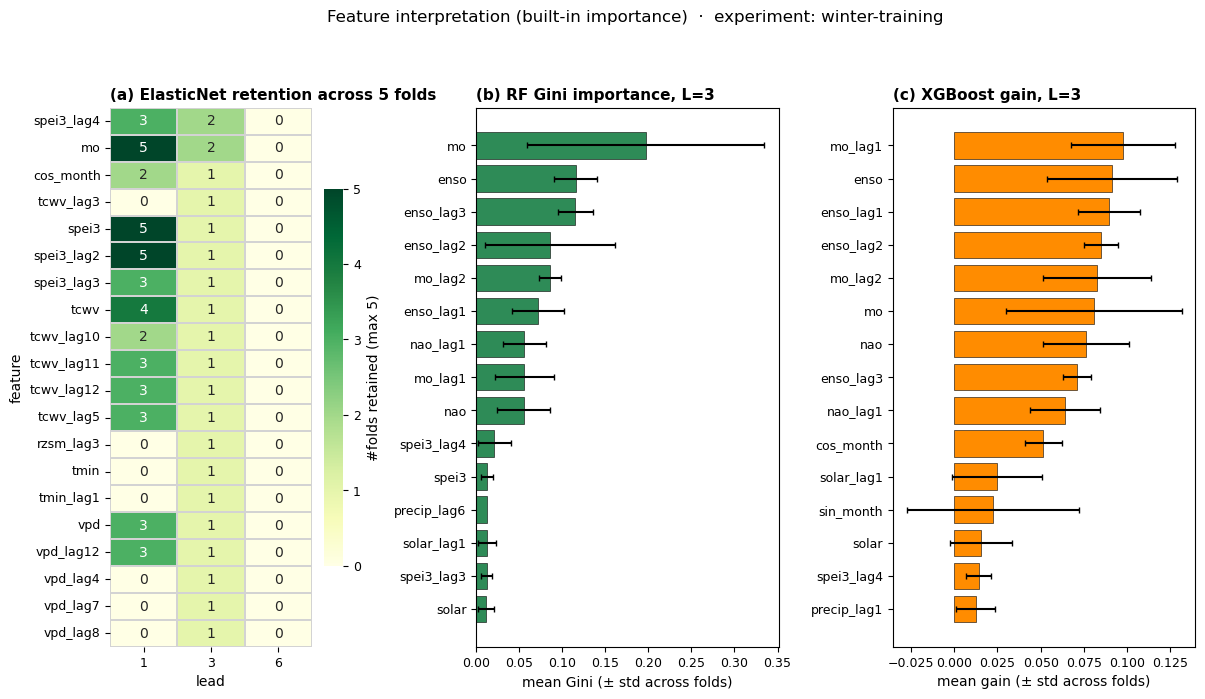

In [6]:
HEADLINE_LEAD = 3 if 3 in leads else int(np.median(leads))
n_folds = feat[feat['kind'] == 'coef']['fold'].nunique()
TOP_N = 15

# Panel (a) — ElasticNet (or Lasso fallback) retention across folds, headline-lead column sorted
en = feat[feat['model'] == 'elasticnet']
if en.empty:
    en = feat[feat['model'] == 'lasso']
    en_label = 'Lasso'
else:
    en_label = 'ElasticNet'
ret = (en.assign(retained_int=en['retained'].astype(int))
         .groupby(['feature', 'lead'])['retained_int']
         .sum().unstack('lead', fill_value=0))
sort_key = ret[HEADLINE_LEAD] if HEADLINE_LEAD in ret.columns else ret.iloc[:, 0]
ret = ret.loc[sort_key.sort_values(ascending=False).index].head(TOP_N + 5)

# Panels (b) and (c) — built-in importance ONLY (Gini / gain). Filter kind explicitly
# so any post-hoc rows added by scripts/05_compute_posthoc_importance.py don't leak in.
rf_top = (feat.query("model == 'rf' and lead == @HEADLINE_LEAD and kind == 'gini'")
              .groupby('feature')['importance']
              .agg(['mean', 'std'])
              .sort_values('mean', ascending=False)
              .head(TOP_N))

xgb_top = (feat.query("model == 'xgboost' and lead == @HEADLINE_LEAD and kind == 'gain'")
               .groupby('feature')['importance']
               .agg(['mean', 'std'])
               .sort_values('mean', ascending=False)
               .head(TOP_N))

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.2, 1.2], wspace=0.4)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

sns.heatmap(
    ret, ax=ax_a, cmap='YlGn', vmin=0, vmax=n_folds,
    annot=True, fmt='d', linewidths=0.3, linecolor='lightgray',
    cbar_kws={'label': f'#folds retained (max {n_folds})', 'shrink': 0.7},
)
ax_a.set_title(f'(a) {en_label} retention across {n_folds} folds', loc='left', fontweight='bold', fontsize=11)
ax_a.set_xlabel('lead'); ax_a.set_ylabel('feature')

ax_b.barh(rf_top.index[::-1], rf_top['mean'][::-1], xerr=rf_top['std'][::-1],
          color='seagreen', edgecolor='black', linewidth=0.4, capsize=2)
ax_b.set_title(f'(b) RF Gini importance, L={HEADLINE_LEAD}', loc='left', fontweight='bold', fontsize=11)
ax_b.set_xlabel('mean Gini (± std across folds)')

ax_c.barh(xgb_top.index[::-1], xgb_top['mean'][::-1], xerr=xgb_top['std'][::-1],
          color='darkorange', edgecolor='black', linewidth=0.4, capsize=2)
ax_c.set_title(f'(c) XGBoost gain, L={HEADLINE_LEAD}', loc='left', fontweight='bold', fontsize=11)
ax_c.set_xlabel('mean gain (± std across folds)')

fig.suptitle(_ttl('Feature interpretation (built-in importance)'), y=1.02)
save_paper(fig, 'fig04_feature_importance')
plt.show()

## Figure 5 — Per-fold stability

Pooled metrics tell the headline story but hide variability. Two models with the same pooled MSSS can have very different fold-to-fold profiles: one consistent, one a coin flip. The panel below shows mean ± std of MSSS across the 5 CV folds per (model, lead), with individual fold values overlaid as black dots. **Tall error bars + scattered dots = unstable model; tight error bars + clustered dots = reliable model.**

Reads the per-fold rows added by `scripts/04_backfill_per_fold_metrics.py` (or by the updated pipeline). Pooled rows are excluded — they're already in Figure 2.

  -> results/figures/10_winter-training/09_paper/fig05_stability.{pdf,png}


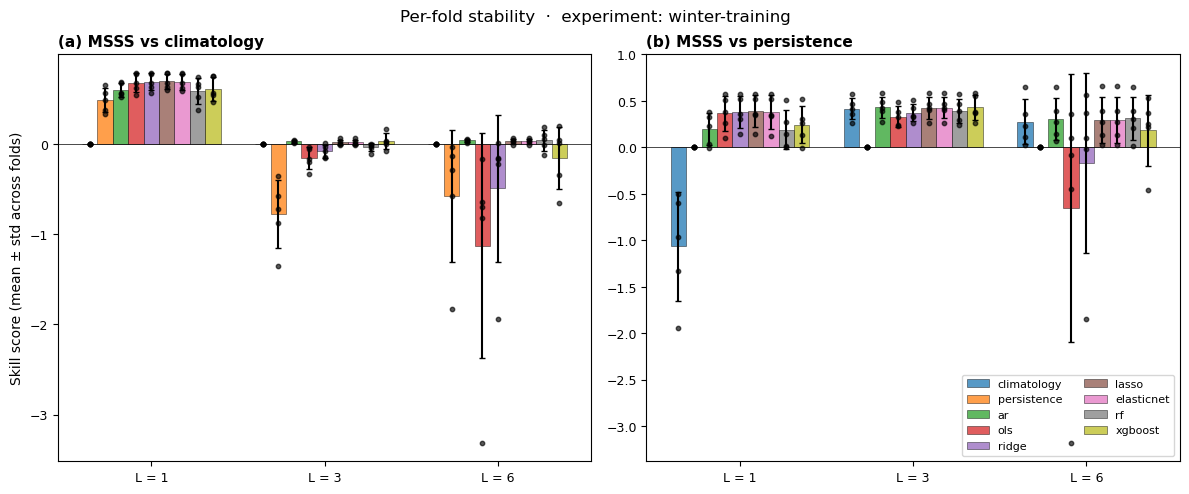


Per-fold MSSS-vs-climatology summary (winter pool):
  → results/figures/10_winter-training/09_paper/per_fold_stability_msss_vs_clim.csv

                   mean    std    min    max
model       lead                            
climatology 1     0.000  0.000  0.000  0.000
            3     0.000  0.000  0.000  0.000
            6     0.000  0.000  0.000  0.000
persistence 1     0.485  0.136  0.332  0.660
            3    -0.775  0.375 -1.350 -0.356
            6    -0.572  0.733 -1.833 -0.033
ar          1     0.600  0.074  0.522  0.684
            3     0.028  0.012  0.015  0.046
            6     0.039  0.017  0.017  0.061
ols         1     0.681  0.106  0.542  0.790
            3    -0.156  0.118 -0.327 -0.035
            6    -1.126  1.247 -3.313 -0.165
ridge       1     0.689  0.094  0.566  0.783
            3    -0.082  0.069 -0.152  0.007
            6    -0.491  0.812 -1.936  0.016
lasso       1     0.695  0.086  0.595  0.784
            3     0.019  0.031 -0.008  0.067
       

In [7]:
per_fold = metrics_df.query("fold != 'pooled' and evaluation_window == 'winter_only'").copy()
per_fold['fold'] = per_fold['fold'].astype(int)

if per_fold.empty:
    print("No per-fold rows found in metrics_allLeads.csv.")
    print("Run:  python scripts/04_backfill_per_fold_metrics.py")
else:
    n_models = len(models_present)
    width = 0.8 / n_models
    x = np.arange(len(leads))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    for ax, metric_name, title in [
        (axes[0], 'msss_vs_climatology', '(a) MSSS vs climatology'),
        (axes[1], 'msss_vs_persistence', '(b) MSSS vs persistence'),
    ]:
        sub = per_fold[per_fold['metric'] == metric_name]
        for i, mdl in enumerate(models_present):
            s = sub[sub['model'] == mdl]
            if s.empty:
                continue
            stats = s.groupby('lead')['value'].agg(['mean', 'std']).reindex(leads)
            xs = x + (i - n_models / 2 + 0.5) * width
            ax.bar(
                xs, stats['mean'].values,
                yerr=stats['std'].fillna(0).values,
                width=width, capsize=2.0,
                edgecolor='black', linewidth=0.4,
                color=colors.get(mdl, None), label=mdl, alpha=0.75,
            )
            # Overlay individual fold values as dots
            for L_idx, L in enumerate(leads):
                vals = s[s['lead'] == L]['value'].values
                if len(vals):
                    ax.scatter(
                        np.full(len(vals), xs[L_idx]), vals,
                        s=10, color='black', alpha=0.65, zorder=10,
                    )
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xticks(x); ax.set_xticklabels([f'L = {L}' for L in leads])
        ax.set_title(title, loc='left', fontweight='bold', fontsize=11)

    axes[0].set_ylabel('Skill score (mean ± std across folds)')
    axes[1].legend(loc='lower right', ncol=2, fontsize=8)
    plt.tight_layout()
    fig.suptitle(_ttl('Per-fold stability'), y=1.02)
    save_paper(fig, 'fig05_stability')
    plt.show()

    # Numerical summary — paste-friendly table of per-fold stability
    print('\nPer-fold MSSS-vs-climatology summary (winter pool):')
    summary = (per_fold[per_fold['metric'] == 'msss_vs_climatology']
        .groupby(['model', 'lead'])['value']
        .agg(['mean', 'std', 'min', 'max'])
        .round(3))
    summary.columns = ['mean', 'std', 'min', 'max']
    summary = summary.loc[[(m, L) for m in models_present for L in leads]]
    out = PAPER_DIR / 'per_fold_stability_msss_vs_clim.csv'
    summary.to_csv(out)
    print(f'  → {out.relative_to(ROOT)}\n')
    print(summary)

## Figure 6 — Post-hoc feature importance (permutation / SHAP)

Companion to Figure 4. Built-in tree importances (Gini, gain) have known biases:
- they under-credit **correlated features** (when SPEI3_lag1 and RZSM_lag1 carry the same signal, the tree picks one for splits and the other is reported as ~unused);
- they over-credit **high-cardinality continuous features** vs categorical / discrete ones.

The two methods below compute importance differently and from the **out-of-sample test slice**, so they sidestep both biases:

- **(a) RF — permutation importance**: model-agnostic. For each feature, randomly shuffle its column at test time and measure the drop in skill (neg-MSE). The bigger the drop, the more the model relied on that feature.
- **(b) XGBoost — TreeSHAP mean(|SHAP|)**: theoretically grounded Shapley-value attribution that explicitly distributes credit across correlated features.

Where the two methods agree, the ranking is robust. Where they disagree, that's a multicollinearity signal — worth flagging in the paper Discussion.

Rows are produced by `scripts/05_compute_posthoc_importance.py`. If `feature_status.csv` doesn't yet contain `kind='permutation'` or `kind='shap_mean_abs'` rows, this cell prints a hint and skips.

  -> results/figures/10_winter-training/09_paper/fig06_post-hoc.{pdf,png}


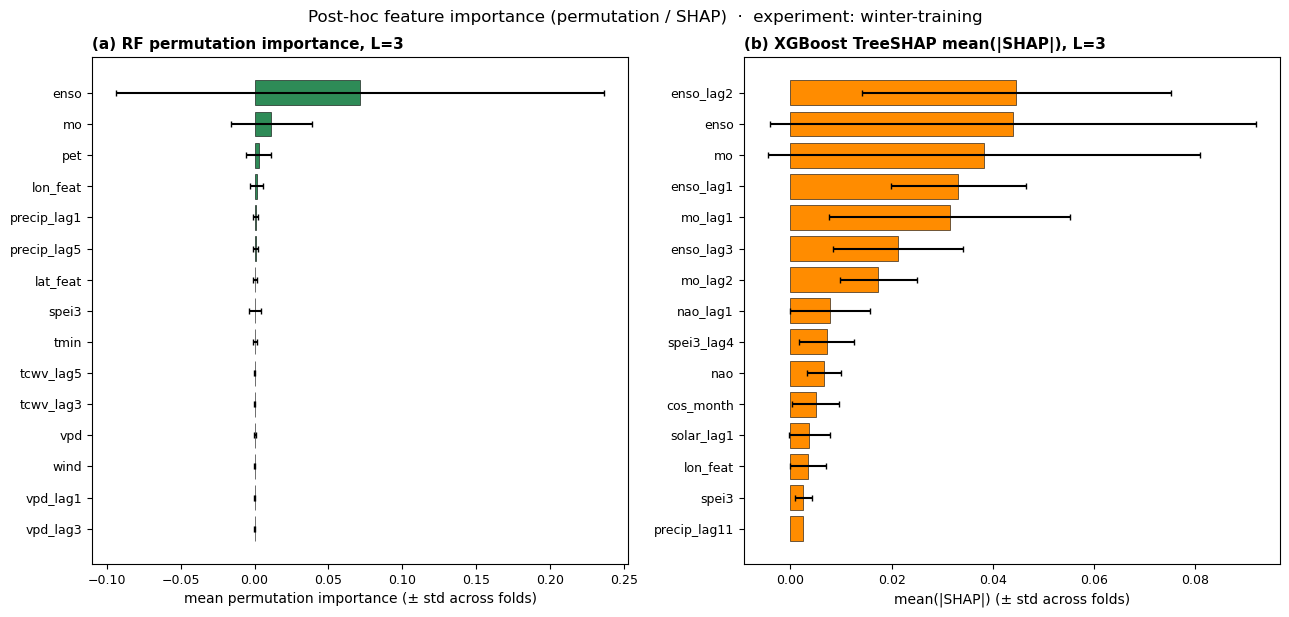


Top-10 overlap between RF permutation and XGBoost SHAP: 2/10  (enso, mo)


In [8]:
# Self-contained — recompute HEADLINE_LEAD and TOP_N locally so this
# cell can run standalone (the @-variable syntax inside pandas.query
# needs them in the local namespace).
HEADLINE_LEAD = 3 if 3 in leads else int(np.median(leads))
TOP_N = 15

rf_posthoc = feat.query(
    "model == 'rf' and lead == @HEADLINE_LEAD and kind == 'permutation'"
)
xgb_posthoc = feat.query(
    "model == 'xgboost' and lead == @HEADLINE_LEAD and kind == 'shap_mean_abs'"
)

if rf_posthoc.empty and xgb_posthoc.empty:
    print("No post-hoc importance rows found in feature_status.csv.")
    print("Run:  python scripts/05_compute_posthoc_importance.py "
          "--exp-config configs/experiments/exp_default.yaml")
else:
    rf_top = (rf_posthoc
        .groupby('feature')['importance']
        .agg(['mean', 'std'])
        .sort_values('mean', ascending=False)
        .head(TOP_N))
    xgb_top = (xgb_posthoc
        .groupby('feature')['importance']
        .agg(['mean', 'std'])
        .sort_values('mean', ascending=False)
        .head(TOP_N))

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    if not rf_top.empty:
        axes[0].barh(rf_top.index[::-1], rf_top['mean'][::-1], xerr=rf_top['std'][::-1],
                     color='seagreen', edgecolor='black', linewidth=0.4, capsize=2)
        axes[0].set_title(f'(a) RF permutation importance, L={HEADLINE_LEAD}',
                          loc='left', fontweight='bold', fontsize=11)
        axes[0].set_xlabel('mean permutation importance (± std across folds)')
    else:
        axes[0].text(0.5, 0.5, "no RF permutation rows", ha='center', va='center',
                     transform=axes[0].transAxes)
        axes[0].set_title('(a) RF permutation importance', loc='left', fontweight='bold', fontsize=11)

    if not xgb_top.empty:
        axes[1].barh(xgb_top.index[::-1], xgb_top['mean'][::-1], xerr=xgb_top['std'][::-1],
                     color='darkorange', edgecolor='black', linewidth=0.4, capsize=2)
        axes[1].set_title(f'(b) XGBoost TreeSHAP mean(|SHAP|), L={HEADLINE_LEAD}',
                          loc='left', fontweight='bold', fontsize=11)
        axes[1].set_xlabel('mean(|SHAP|) (± std across folds)')
    else:
        axes[1].text(0.5, 0.5, "no XGBoost SHAP rows", ha='center', va='center',
                     transform=axes[1].transAxes)
        axes[1].set_title('(b) XGBoost TreeSHAP', loc='left', fontweight='bold', fontsize=11)

    plt.tight_layout()
    fig.suptitle(_ttl('Post-hoc feature importance (permutation / SHAP)'), y=1.02)
    save_paper(fig, 'fig06_post-hoc')
    plt.show()

    # Quick agreement summary — how often do permutation and SHAP top-10 overlap?
    if not rf_top.empty and not xgb_top.empty:
        rf_top10 = set(rf_top.head(10).index)
        xgb_top10 = set(xgb_top.head(10).index)
        common = rf_top10 & xgb_top10
        print(f'\nTop-10 overlap between RF permutation and XGBoost SHAP: '
              f'{len(common)}/10  ({", ".join(sorted(common)) if common else "(none)"})')

## Figure 7 — Predicted vs Truth scatter

For each lead L ∈ {1, 3, 6} a separate figure with a 3 × 3 grid of model panels. Each panel scatters predicted SPEI3 against observed SPEI3 over the pooled OOS window (Morocco cells × 2000-2024), colour-coded by the **target month** (cyclic palette so Dec→Jan wraps cleanly).

A 1:1 reference line marks perfect calibration; points above are over-forecasts and below are under-forecasts. Each panel also reports R² and the number of finite samples.

To keep the figures readable at ~49 k pooled samples per (model, lead), points are randomly subsampled to 5 000 with a fixed seed.

  -> results/figures/10_winter-training/09_paper/fig07_pred_vs_truth_L1.{pdf,png}


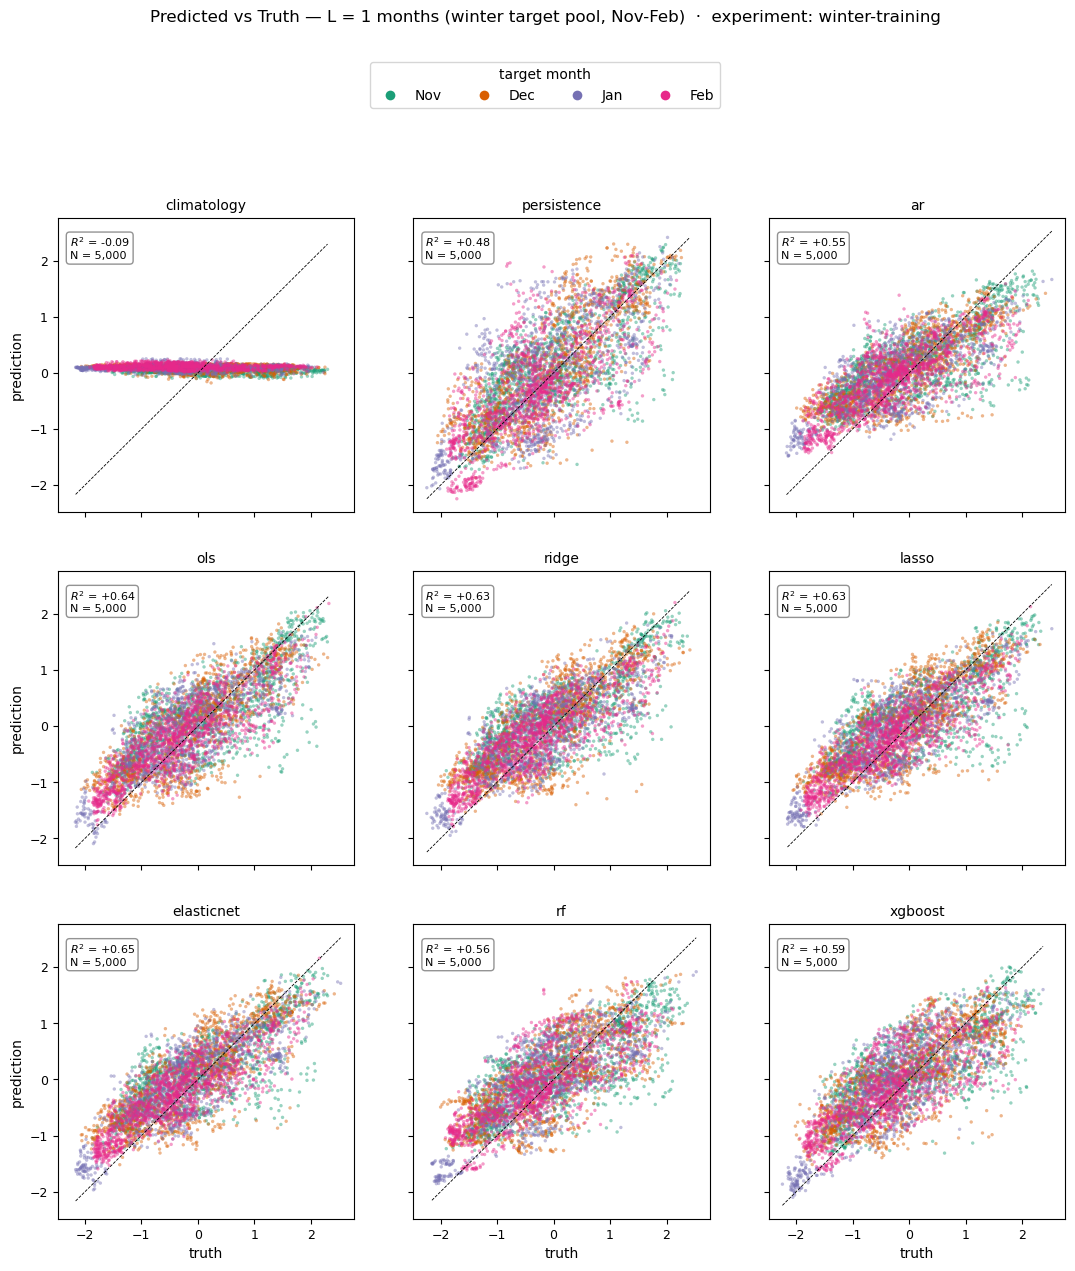

  -> results/figures/10_winter-training/09_paper/fig07_pred_vs_truth_L3.{pdf,png}


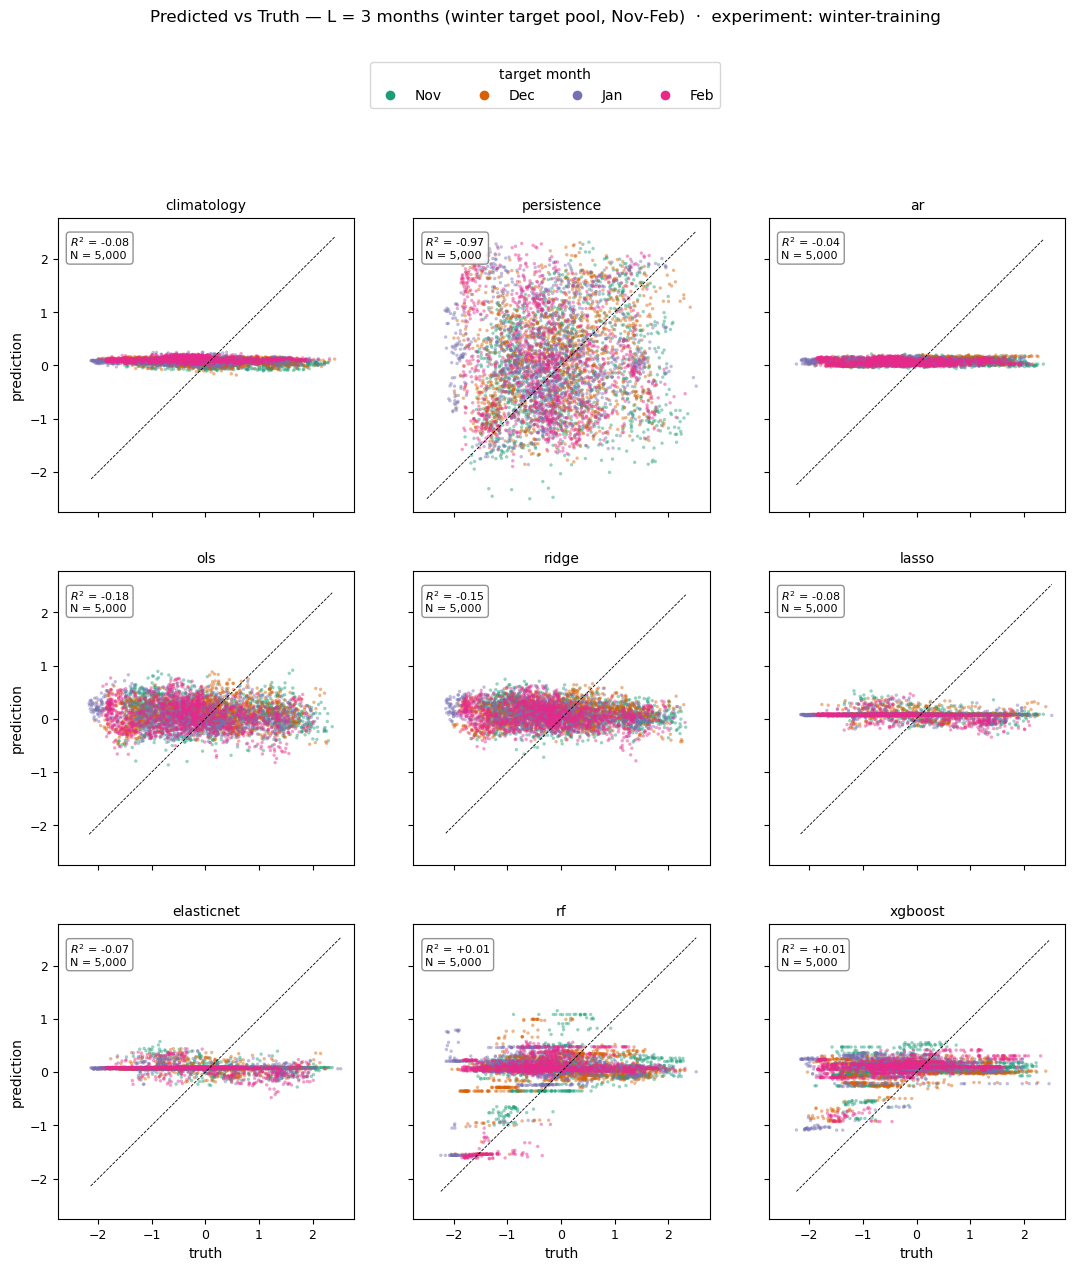

  -> results/figures/10_winter-training/09_paper/fig07_pred_vs_truth_L6.{pdf,png}


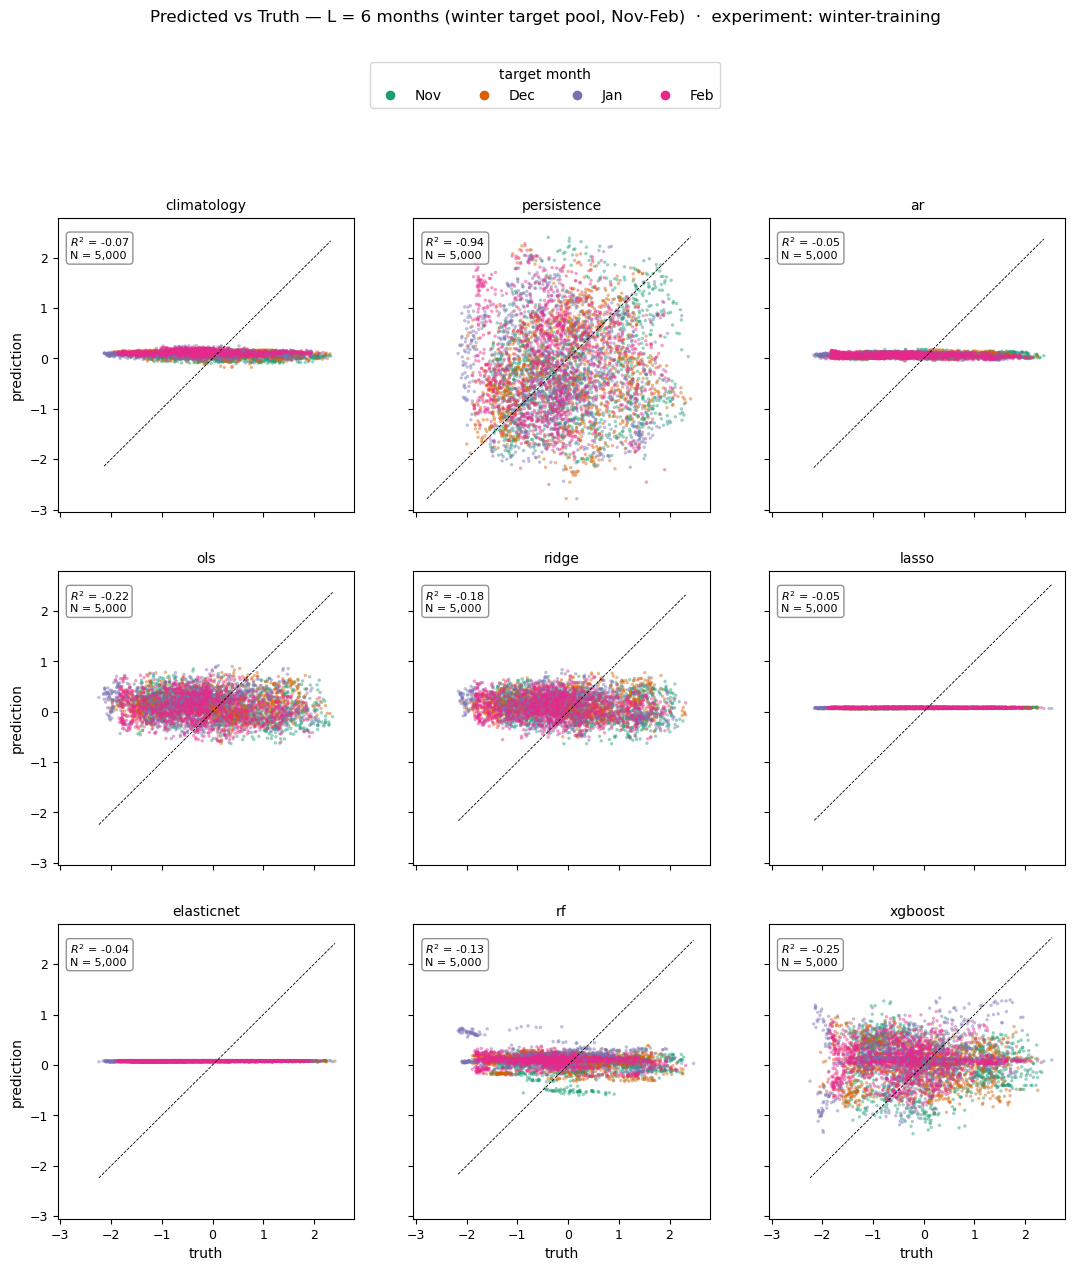

In [9]:
rng = np.random.default_rng(42)
SUBSAMPLE_N = 5000
time_idx = pd.DatetimeIndex(ds_preds['time'].values)

# Distinct, color-blind-safe palette for the 4 winter target months.
WINTER_MONTHS = [11, 12, 1, 2]
WINTER_LABEL = {11: 'Nov', 12: 'Dec', 1: 'Jan', 2: 'Feb'}
WINTER_COLOURS = {11: '#1b9e77', 12: '#d95f02', 1: '#7570b3', 2: '#e7298a'}  # ColorBrewer Dark2 (first 4)

def _flatten_morocco(arr, mask_2d):
    mask_flat = mask_2d.values.ravel().astype(bool)
    return arr.reshape(arr.shape[0], -1)[:, mask_flat].ravel()

mask_2d = morocco_mask

for L in leads:
    truth_arr = ds_preds['truth'].sel(lead=L).values
    target_months = (time_idx + pd.DateOffset(months=int(L))).month.values
    n_cells = int(mask_2d.values.sum())
    months_full = np.repeat(target_months, n_cells)
    truth_flat = _flatten_morocco(truth_arr, mask_2d)

    fig, axes = plt.subplots(3, 3, figsize=(13, 13), sharex=True, sharey=True)
    for ax, mdl in zip(axes.flat, models_present):
        pred_arr = ds_preds[f'pred_{mdl}'].sel(lead=L).values
        pred_flat = _flatten_morocco(pred_arr, mask_2d)
        finite = np.isfinite(truth_flat) & np.isfinite(pred_flat)
        winter = np.isin(months_full, WINTER_MONTHS)
        keep = finite & winter
        x, y, m = truth_flat[keep], pred_flat[keep], months_full[keep]
        if len(x) > SUBSAMPLE_N:
            idx = rng.choice(len(x), size=SUBSAMPLE_N, replace=False)
            x, y, m = x[idx], y[idx], m[idx]
        # Plot each winter month with its distinct colour
        for month_num in WINTER_MONTHS:
            sel = (m == month_num)
            ax.scatter(x[sel], y[sel],
                       color=WINTER_COLOURS[month_num], label=WINTER_LABEL[month_num],
                       s=6, alpha=0.45, linewidths=0, edgecolors='none')
        lo = float(np.nanmin([x.min(), y.min()])); hi = float(np.nanmax([x.max(), y.max()]))
        ax.plot([lo, hi], [lo, hi], color='black', linewidth=0.6, linestyle='--')
        ss_res = float(np.sum((x - y) ** 2))
        ss_tot = float(np.sum((x - x.mean()) ** 2)) or 1.0
        r2 = 1.0 - ss_res / ss_tot
        ax.text(0.04, 0.94, f'$R^2$ = {r2:+.2f}\nN = {len(x):,}',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.3'))
        ax.set_title(mdl, fontsize=10)
        ax.set_xlabel('truth' if ax in axes[-1] else '')
        ax.set_ylabel('prediction' if ax in axes[:, 0] else '')

    # One shared legend for the 4 winter months
    handles = [plt.Line2D([], [], marker='o', linestyle='', markersize=7,
                          markerfacecolor=WINTER_COLOURS[m], markeredgecolor='none', label=WINTER_LABEL[m])
               for m in WINTER_MONTHS]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.005),
               ncol=4, fontsize=10, frameon=True, title='target month')
    fig.suptitle(_ttl(f'Predicted vs Truth — L = {int(L)} months (winter target pool, Nov-Feb)'), y=1.04)
    save_paper(fig, f'fig07_pred_vs_truth_L{int(L)}')
    plt.show()


## Figure 8 — Validation vs Test (overfitting diagnostic)

Per (fold, lead, model) point: validation RMSE (derived from the HP-search's `best_val_score = −val_MSE`) on the x-axis, test RMSE (per-fold from the metrics CSV) on the y-axis. Each model is a colour; each lead a marker shape.

**Reading the plot**:
- Points on the 1:1 line = val skill matches test skill (good generalization).
- Points well **above** the diagonal = test worse than val → likely overfitting to val noise during the HP search.
- Points well **below** the diagonal = test better than val. Caveat: this is **not** automatic luck — Protocol A refits on (train ∪ val) before scoring on test, so the test-model has seen more data than the val-model. Some downward drift is expected and healthy.

Baselines (climatology / persistence / AR) and OLS are excluded — they have no HP search and therefore no `best_val_score`.

val-vs-test points: 75  (models = ['elasticnet', 'lasso', 'rf', 'ridge', 'xgboost'])
train_rmse column present and populated: True


  -> results/figures/10_winter-training/09_paper/fig08_generalization_diagnostic.{pdf,png}


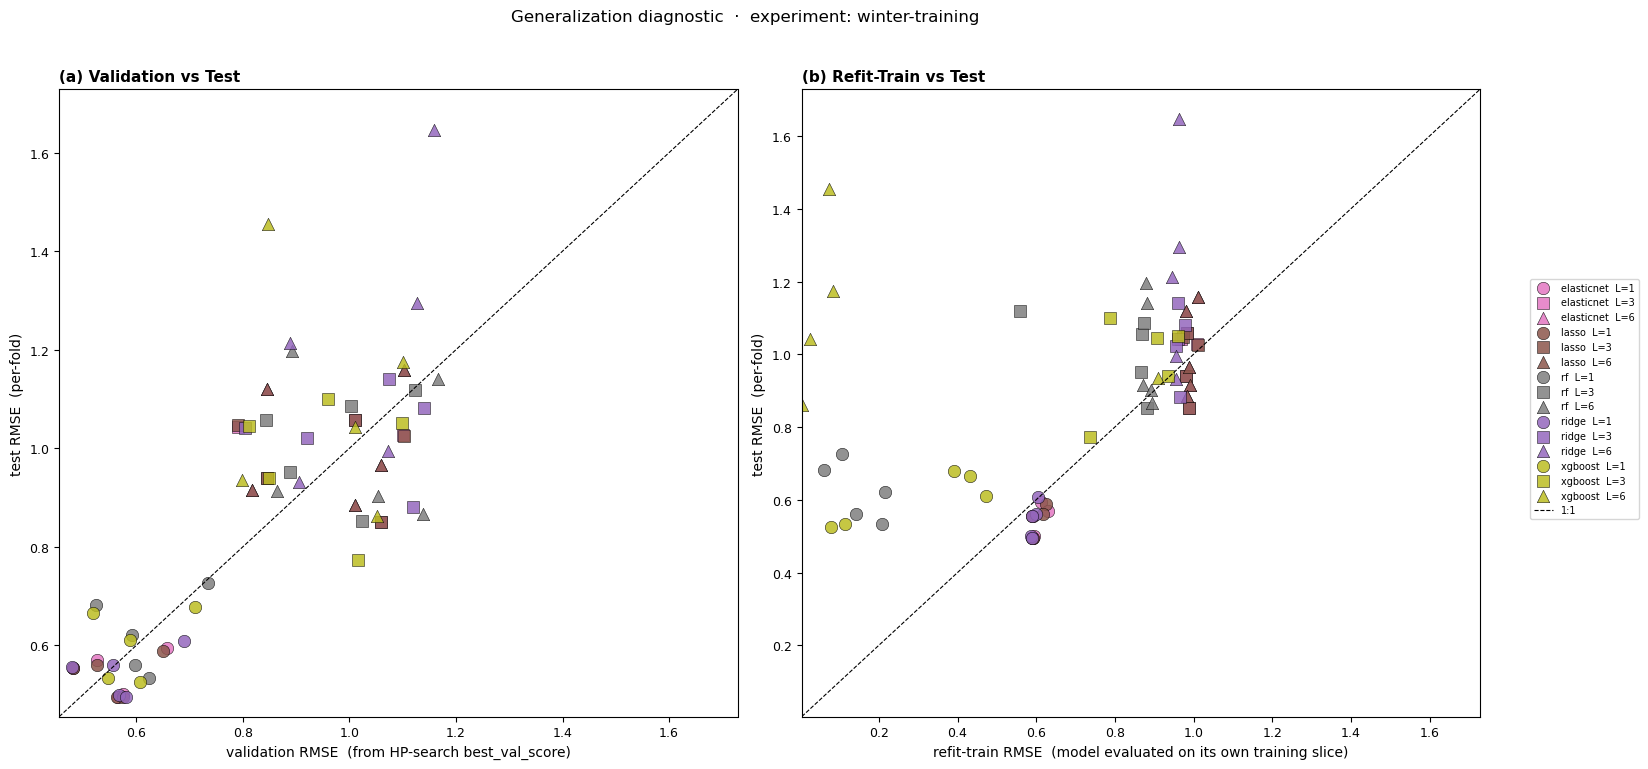

In [10]:
fold_runs_path = RESULTS_DIR / 'winter-training' / 'logs' / 'fold_runs.csv'
fold_runs = pd.read_csv(fold_runs_path)

# val_RMSE assumes scoring='neg_mse' (pipeline default).
val = (fold_runs[['model', 'lead', 'fold', 'best_val_score']]
       .dropna(subset=['best_val_score'])
       .assign(val_rmse=lambda d: np.sqrt(-d['best_val_score'])))

# Per-fold test RMSE on the winter pool
test_perfold = metrics_df.query(
    "fold != 'pooled' and metric == 'rmse' and evaluation_window == 'winter_only'"
).copy()
test_perfold['fold'] = test_perfold['fold'].astype(int)
test_perfold = test_perfold.rename(columns={'value': 'test_rmse'})[['model', 'lead', 'fold', 'test_rmse']]

merged = val.merge(test_perfold, on=['model', 'lead', 'fold'], how='inner')

# Is train_rmse available?  Only filled by scripts/06_compute_refit_train_rmse.py
# when save_models was on (winter / pruned-winter sweeps).
has_train = 'train_rmse' in fold_runs.columns and fold_runs['train_rmse'].notna().any()
if has_train:
    train = fold_runs[['model', 'lead', 'fold', 'train_rmse']].dropna(subset=['train_rmse'])
    merged = merged.merge(train, on=['model', 'lead', 'fold'], how='left')

print(f'val-vs-test points: {len(merged)}  '
      f'(models = {sorted(merged["model"].unique())})')
print(f'train_rmse column present and populated: {has_train}')

if merged.empty:
    print('No HP-tuned models found in fold_runs.csv. Skipping Figure 8.')
else:
    lead_markers = {1: 'o', 3: 's', 6: '^'}
    n_panels = 2 if has_train else 1
    fig, axes = plt.subplots(1, n_panels, figsize=(7.5 * n_panels, 7.5), squeeze=False)
    ax_left = axes[0, 0]

    def _scatter_panel(ax, x_col, y_col, xlabel, ylabel, title):
        for mdl in sorted(merged['model'].unique()):
            for L in leads:
                sub = merged.query("model == @mdl and lead == @L")
                if sub.empty: continue
                ax.scatter(sub[x_col], sub[y_col],
                           color=colors.get(mdl), marker=lead_markers.get(int(L), 'o'),
                           s=80, alpha=0.85, edgecolors='black', linewidths=0.4,
                           label=f'{mdl}  L={L}')
        lo = float(min(merged[x_col].min(), merged[y_col].min())) * 0.95
        hi = float(max(merged[x_col].max(), merged[y_col].max())) * 1.05
        ax.plot([lo, hi], [lo, hi], color='black', linewidth=0.8, linestyle='--', label='1:1')
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(title, loc='left', fontweight='bold', fontsize=11)

    _scatter_panel(ax_left, 'val_rmse', 'test_rmse',
                   'validation RMSE  (from HP-search best_val_score)',
                   'test RMSE  (per-fold)',
                   '(a) Validation vs Test')
    if has_train:
        # Some baselines / OLS without HP search may not have train_rmse merged
        m_train = merged.dropna(subset=['train_rmse'])
        if not m_train.empty:
            ax_right = axes[0, 1]
            for mdl in sorted(m_train['model'].unique()):
                for L in leads:
                    sub = m_train.query("model == @mdl and lead == @L")
                    if sub.empty: continue
                    ax_right.scatter(sub['train_rmse'], sub['test_rmse'],
                                     color=colors.get(mdl), marker=lead_markers.get(int(L), 'o'),
                                     s=80, alpha=0.85, edgecolors='black', linewidths=0.4)
            lo = float(min(m_train['train_rmse'].min(), m_train['test_rmse'].min())) * 0.95
            hi = float(max(m_train['train_rmse'].max(), m_train['test_rmse'].max())) * 1.05
            ax_right.plot([lo, hi], [lo, hi], color='black', linewidth=0.8, linestyle='--')
            ax_right.set_xlim(lo, hi); ax_right.set_ylim(lo, hi)
            ax_right.set_xlabel('refit-train RMSE  (model evaluated on its own training slice)')
            ax_right.set_ylabel('test RMSE  (per-fold)')
            ax_right.set_title('(b) Refit-Train vs Test', loc='left', fontweight='bold', fontsize=11)

    # Single shared legend on the right
    handles, labels = ax_left.get_legend_handles_labels()
    fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left',
               fontsize=7, ncol=1)
    fig.suptitle(_ttl('Generalization diagnostic'), y=1.02)
    plt.tight_layout()
    save_paper(fig, 'fig08_generalization_diagnostic')
    plt.show()


## Figures 9 & 10 — Per-cell MAE and RMSE spatial maps

Companion to the existing per-cell MSSS-vs-climatology grid (in `notebook 07`). These two figures show the **raw** error magnitude per Morocco cell for each (model × lead), measured on the winter target pool. Sequential colormap — darker = larger error.

- **Figure 9**: per-cell MAE = mean(|pred − truth|) over winter target months
- **Figure 10**: per-cell RMSE = √(mean((pred − truth)²)) over winter target months

Compared with MSSS, these have the advantage that "good" and "bad" are on the absolute SPEI3 z-score scale (interpretable as anomaly units), and don't require a reference model. The disadvantage: a cell with naturally lower variance will show a smaller raw error even with no real skill, so MAE/RMSE maps complement MSSS rather than replace it.

/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_74178/3309587620.py:7: RuntimeWarning: Mean of empty slice
  out = np.nanmean(np.abs(yp - yt), axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_74178/3309587620.py:13: RuntimeWarning: Mean of empty slice
  out = np.sqrt(np.nanmean((yp - yt) ** 2, axis=0))
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_74178/3309587620.py:7: RuntimeWarning: Mean of empty slice
  out = np.nanmean(np.abs(yp - yt), axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_74178/3309587620.py:13: RuntimeWarning: Mean of empty slice
  out = np.sqrt(np.nanmean((yp - yt) ** 2, axis=0))
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_74178/3309587620.py:7: RuntimeWarning: Mean of empty slice
  out = np.nanmean(np.abs(yp - yt), axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_74178/3309587620.py:13: RuntimeWarning: Mean of empty slice
  out = np.sqrt(np.nanmean((yp - yt) ** 2, axis=0))


  -> results/figures/10_winter-training/09_paper/fig09_per_cell_mae.{pdf,png}


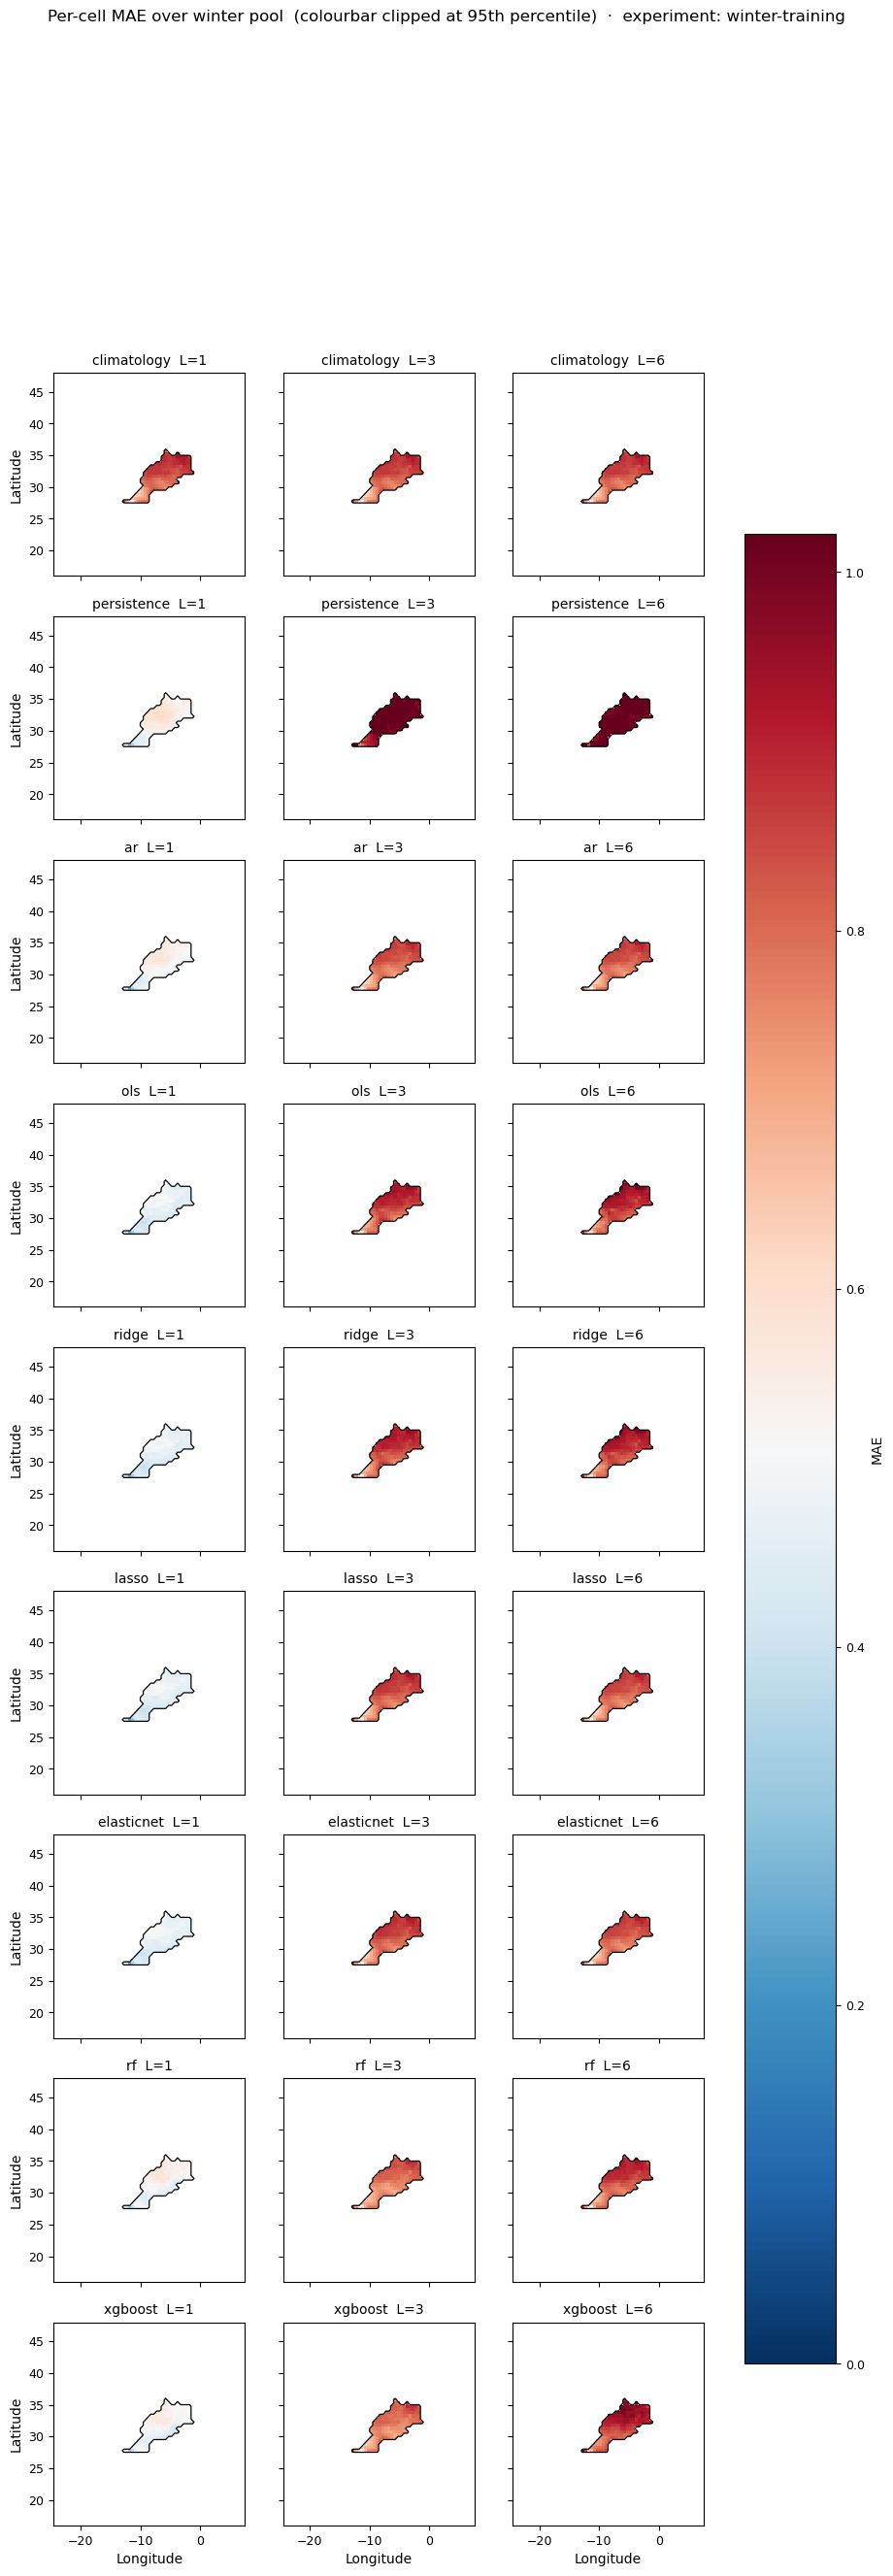

  -> results/figures/10_winter-training/09_paper/fig10_per_cell_rmse.{pdf,png}


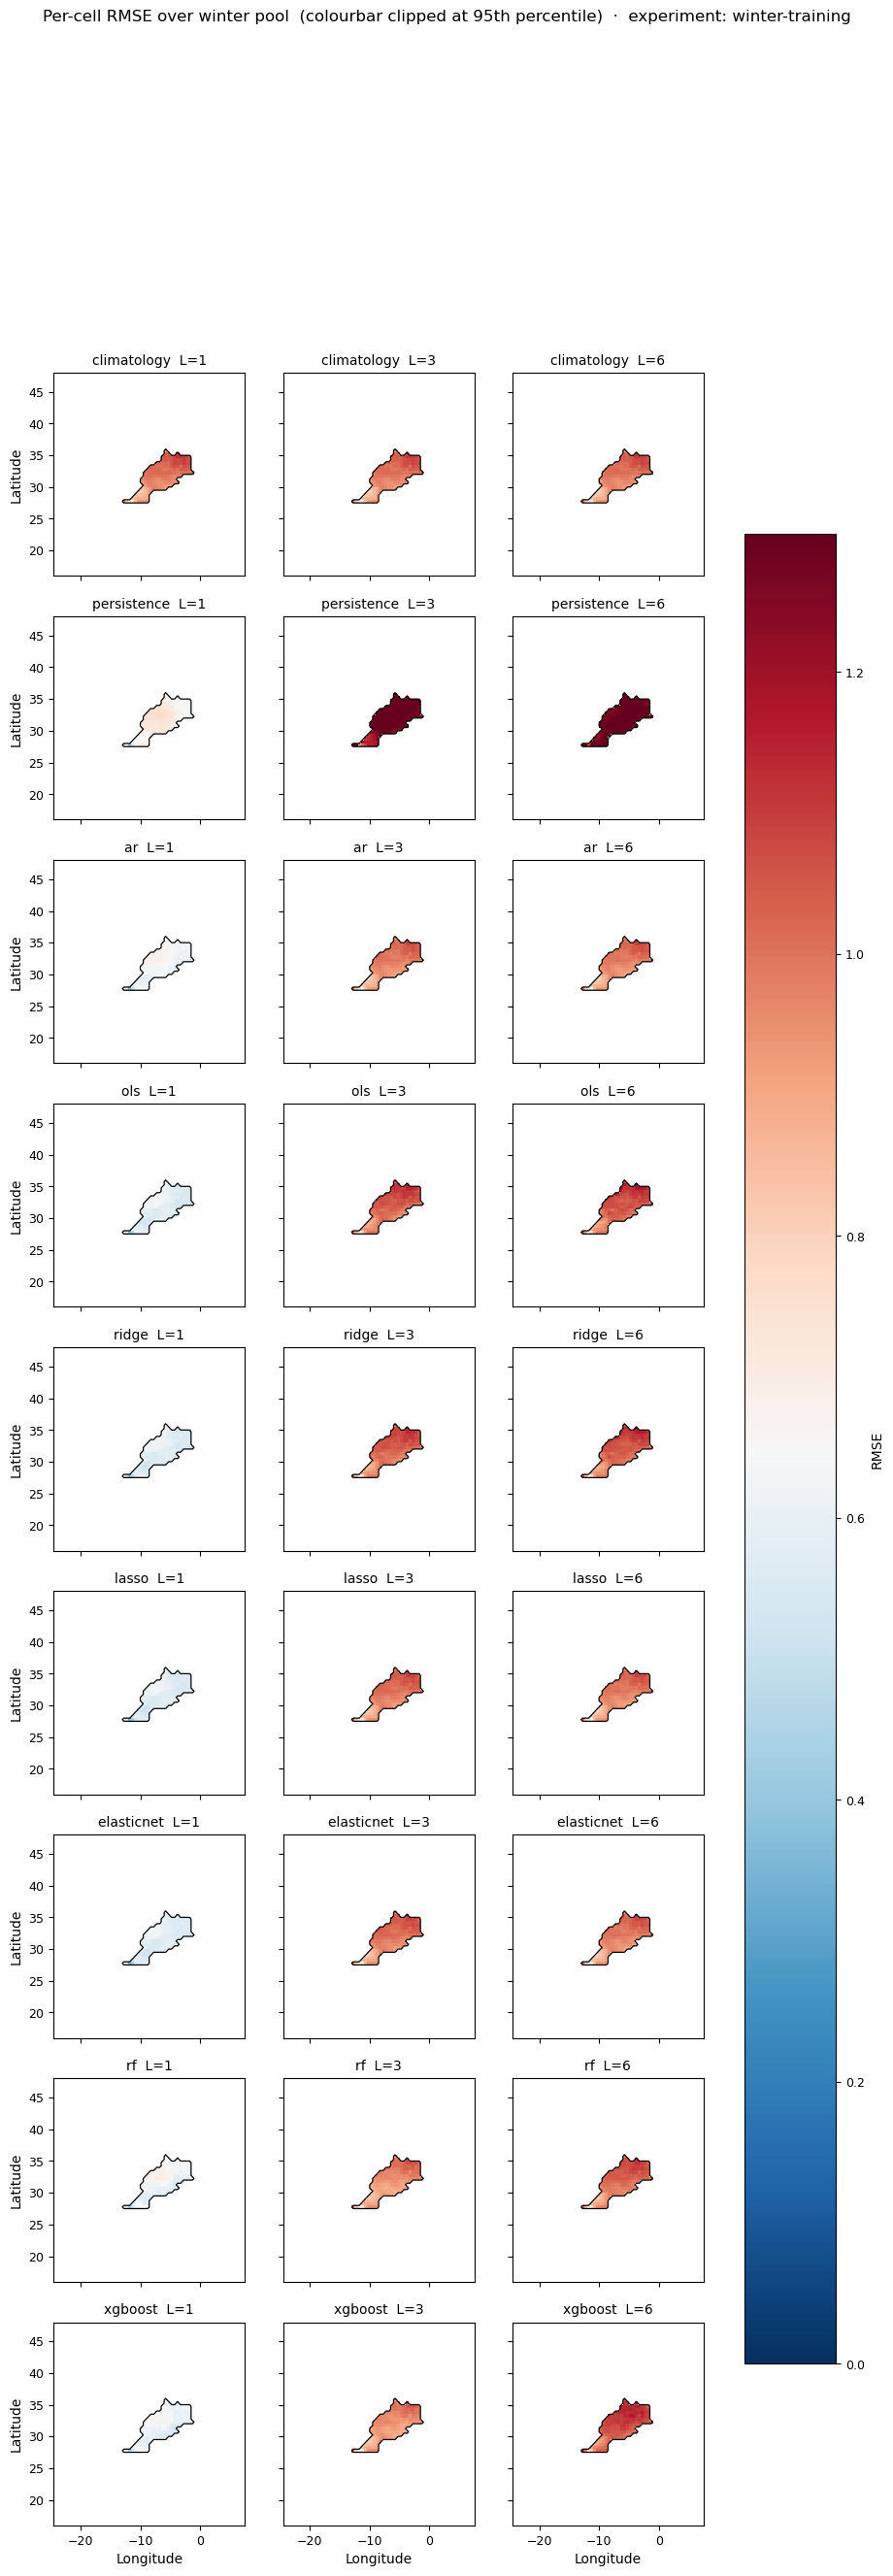


Morocco-mean per-cell error summary (lower = better):
            mean_MAE               mean_RMSE              
lead               1      3      6         1      3      6
model                                                     
climatology    0.823  0.819  0.819     0.985  0.982  0.982
persistence    0.541  1.043  1.061     0.697  1.322  1.332
ar             0.516  0.800  0.804     0.631  0.965  0.967
ols            0.462  0.853  0.873     0.576  1.026  1.044
ridge          0.462  0.849  0.864     0.572  1.019  1.034
lasso          0.461  0.820  0.806     0.570  0.983  0.968
elasticnet     0.465  0.822  0.806     0.571  0.985  0.968
rf             0.513  0.779  0.835     0.626  0.943  1.006
xgboost        0.502  0.772  0.885     0.613  0.937  1.068


In [11]:
def _winter_mask_at(L: int):
    target_m = (pd.DatetimeIndex(ds_preds['time'].values) + pd.DateOffset(months=int(L))).month
    return np.isin(target_m, [11, 12, 1, 2])

def per_cell_mae(pred, truth, winter_mask_t, mask):
    yp, yt = pred[winter_mask_t], truth[winter_mask_t]
    out = np.nanmean(np.abs(yp - yt), axis=0)
    out[~mask.values] = np.nan
    return out

def per_cell_rmse(pred, truth, winter_mask_t, mask):
    yp, yt = pred[winter_mask_t], truth[winter_mask_t]
    out = np.sqrt(np.nanmean((yp - yt) ** 2, axis=0))
    out[~mask.values] = np.nan
    return out

mae_grids = {}
rmse_grids = {}
for L in leads:
    wmask = _winter_mask_at(L)
    truth = ds_preds['truth'].sel(lead=L).values
    for mdl in models_present:
        pred = ds_preds[f'pred_{mdl}'].sel(lead=L).values
        mae_grids[(mdl, L)] = per_cell_mae(pred, truth, wmask, morocco_mask)
        rmse_grids[(mdl, L)] = per_cell_rmse(pred, truth, wmask, morocco_mask)

lat_coord = morocco_mask['lat']
lon_coord = morocco_mask['lon']

def _plot_error_grid(grids, label, fname, cmap='RdBu_r'):
    # Use the divergent RdBu_r over a [0, p95] range so low error = blue, high error = red
    # (mirrors notebook 07's spatial skill colour idiom; note MAE/RMSE are non-negative
    # so the colourbar is one-sided).
    vmax = float(np.nanpercentile([v for v in grids.values()], 95))
    fig, axes = plt.subplots(
        len(models_present), len(leads),
        figsize=(3.6 * len(leads), 3.2 * len(models_present)),
        sharex=True, sharey=True,
    )
    if len(models_present) == 1: axes = axes[np.newaxis, :]
    im = None
    for r, mdl in enumerate(models_present):
        for c, L in enumerate(leads):
            ax = axes[r, c]
            da = xr.DataArray(grids[(mdl, L)], dims=('lat', 'lon'),
                              coords={'lat': lat_coord, 'lon': lon_coord})
            im = da.plot(ax=ax, cmap=cmap, vmin=0, vmax=vmax, add_colorbar=False)
            morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black',
                                       linewidths=0.9, add_colorbar=False)
            ax.set_title(f'{mdl}  L={L}', fontsize=10)
            ax.set_xlabel('Longitude' if r == len(models_present) - 1 else '')
            ax.set_ylabel('Latitude' if c == 0 else '')
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), label=label, shrink=0.85)
    fig.suptitle(_ttl(f'Per-cell {label} over winter pool  (colourbar clipped at 95th percentile)'), y=1.01)
    save_paper(fig, fname)
    plt.show()

_plot_error_grid(mae_grids, 'MAE', 'fig09_per_cell_mae', cmap='RdBu_r')
_plot_error_grid(rmse_grids, 'RMSE', 'fig10_per_cell_rmse', cmap='RdBu_r')

print('\nMorocco-mean per-cell error summary (lower = better):')
import pandas as _pd
rows = []
for (mdl, L), g in mae_grids.items():
    rows.append({'model': mdl, 'lead': int(L), 'mean_MAE': float(np.nanmean(g)),
                 'mean_RMSE': float(np.nanmean(rmse_grids[(mdl, L)]))})
print(_pd.DataFrame(rows).pivot_table(index='model', columns='lead',
                                       values=['mean_MAE', 'mean_RMSE']).round(3).loc[models_present])


## Figure 11 — Categorical extremes (drought detection)

The continuous-skill metrics in Figures 1–10 weight every prediction-vs-truth pair equally. For operational drought early warning, the more relevant question is **does the model successfully cross the drought threshold when reality does?** — even if it under-predicts the magnitude (predicts SPEI = −0.5 when truth is −2.0).

Convert predictions and truth to a binary class at **SPEI3 < −1.0** (the conventional "moderate-or-worse drought" threshold; v3 §10.2 already wires HSS at this threshold into the code, switched off in the metrics config by default). Then per (model, lead) on the winter target pool:

- **POD** (Probability of Detection) = TP / (TP + FN) — fraction of actual drought months the model flagged.
- **FAR** (False Alarm Ratio) = FP / (FP + TP) — fraction of flagged months that were not actually drought.

A perfect early-warning system sits at **(FAR = 0, POD = 1)** (top-left). Climatology and persistence are also plotted as references — they're not useless for categorical drought even if their continuous skill is weak.

  → results/figures/10_winter-training/09_paper/categorical_extremes.csv



  -> results/figures/10_winter-training/09_paper/fig11_categorical_extremes.{pdf,png}


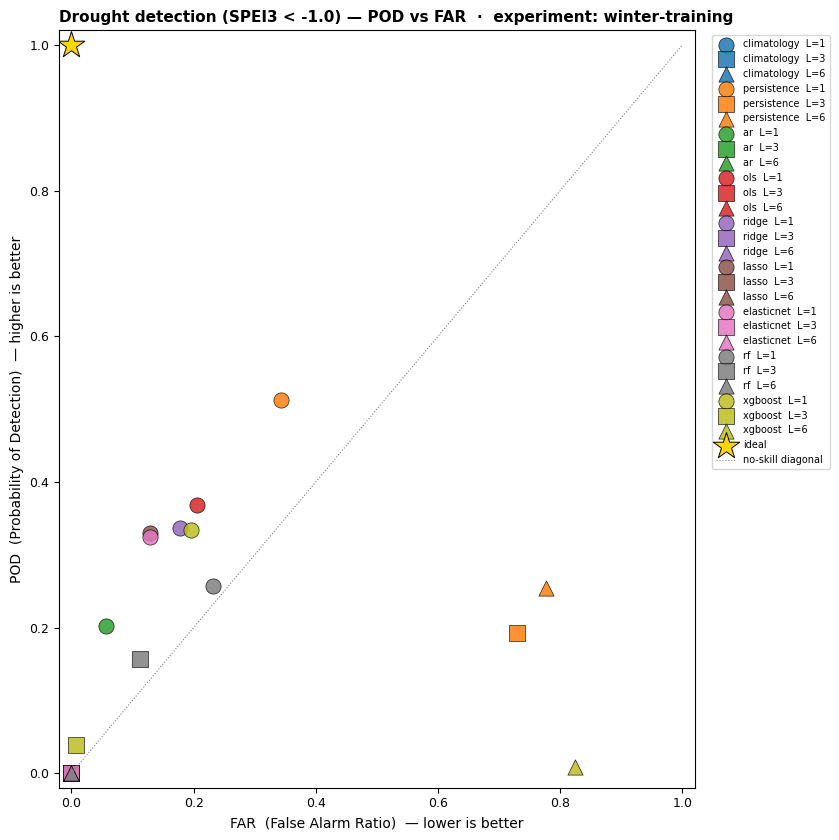

Per-(model, lead) categorical summary:
               FAR                  POD              
lead             1      3      6      1      3      6
model                                                
climatology  0.000  0.000  0.000  0.000  0.000  0.000
persistence  0.343  0.729  0.777  0.513  0.192  0.255
ar           0.057  0.000  0.000  0.202  0.000  0.000
ols          0.206  0.000  0.000  0.369  0.000  0.000
ridge        0.178  0.000  0.000  0.337  0.000  0.000
lasso        0.128  0.000  0.000  0.330  0.000  0.000
elasticnet   0.129  0.000  0.000  0.325  0.000  0.000
rf           0.231  0.112  0.000  0.257  0.156  0.000
xgboost      0.196  0.008  0.824  0.334  0.039  0.008


In [12]:
DROUGHT_THRESHOLD = -1.0

def _categorical_metrics(pred, truth, winter_mask_t, mask_2d):
    """Compute (POD, FAR) for binary drought class on the winter pool."""
    yp, yt = pred[winter_mask_t], truth[winter_mask_t]
    mask_flat = mask_2d.values.ravel().astype(bool)
    yp = yp.reshape(yp.shape[0], -1)[:, mask_flat].ravel()
    yt = yt.reshape(yt.shape[0], -1)[:, mask_flat].ravel()
    finite = np.isfinite(yp) & np.isfinite(yt)
    yp, yt = yp[finite], yt[finite]
    pred_drought = yp < DROUGHT_THRESHOLD
    truth_drought = yt < DROUGHT_THRESHOLD
    TP = int((pred_drought & truth_drought).sum())
    FP = int((pred_drought & ~truth_drought).sum())
    FN = int((~pred_drought & truth_drought).sum())
    TN = int((~pred_drought & ~truth_drought).sum())
    POD = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    FAR = FP / (FP + TP) if (FP + TP) > 0 else 0.0
    return POD, FAR, TP, FP, FN, TN

cat_rows = []
for L in leads:
    wmask = _winter_mask_at(L)
    truth = ds_preds['truth'].sel(lead=L).values
    for mdl in models_present:
        pred = ds_preds[f'pred_{mdl}'].sel(lead=L).values
        POD, FAR, TP, FP, FN, TN = _categorical_metrics(pred, truth, wmask, morocco_mask)
        cat_rows.append({
            'model': mdl, 'lead': int(L),
            'POD': POD, 'FAR': FAR,
            'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
            'n_drought_actual': TP + FN,
        })
cat_df = pd.DataFrame(cat_rows)

# Save CSV for paper-table inclusion
out_csv = PAPER_DIR / 'categorical_extremes.csv'
cat_df.to_csv(out_csv, index=False)
print(f'  → {out_csv.relative_to(ROOT)}\n')

# Scatter: POD vs FAR, color by model, marker by lead
lead_markers = {1: 'o', 3: 's', 6: '^'}
fig, ax = plt.subplots(figsize=(8.5, 8.5))
for mdl in models_present:
    for L in leads:
        sub = cat_df.query("model == @mdl and lead == @L")
        if sub.empty: continue
        ax.scatter(sub['FAR'], sub['POD'],
                   color=colors.get(mdl), marker=lead_markers.get(int(L), 'o'),
                   s=120, alpha=0.85, edgecolors='black', linewidths=0.5,
                   label=f'{mdl}  L={L}')
# Ideal point + naive-coin-flip line
ax.scatter([0], [1], marker='*', s=400, color='gold',
           edgecolors='black', linewidths=0.7, zorder=5, label='ideal')
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=0.8, label='no-skill diagonal')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('FAR  (False Alarm Ratio)  — lower is better')
ax.set_ylabel('POD  (Probability of Detection)  — higher is better')
ax.set_title(_ttl(f'Drought detection (SPEI3 < {DROUGHT_THRESHOLD}) — POD vs FAR'),
             loc='left', fontweight='bold', fontsize=11)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
save_paper(fig, 'fig11_categorical_extremes')
plt.show()

print('Per-(model, lead) categorical summary:')
print(cat_df.pivot_table(index='model', columns='lead', values=['POD', 'FAR']).round(3).loc[models_present])


## Notes

**Files produced** (in `results/figures/09_paper/`):
- `headline_table.csv` — paste-friendly
- `headline_table.tex` — drop straight into the paper LaTeX source (uses `\caption`, `\label{tab:headline_skill}`)
- `fig01_acc_vs_lead.{pdf,png}` — ACC and MSSS-vs-clim vs lead
- `fig02_msss_bars.{pdf,png}` — skill scores by model
- `fig03_spatial_skill.{pdf,png}` — per-cell ACC: baseline / best ML / difference
- `fig04_feature_importance.{pdf,png}` — L1 retention + tree importances

**Best ML model is selected dynamically** (mean MSSS-vs-clim across leads, winter pool) — currently resolves to the model printed in the setup cell. If you want to fix one specific model regardless of metric (e.g. always XGBoost for the spatial figure), edit the `best_ml = ...` line in the setup cell.

**For Overleaf**: drop `headline_table.tex` straight in, and `\includegraphics{fig01_acc_vs_lead.pdf}` (etc.) inside `\begin{figure}` blocks. The 300 dpi PDFs are vector — they'll scale to any column width without artefacts. `pdf.fonttype=42` keeps the text editable in Illustrator if last-minute label tweaks are needed.

**Permutation / SHAP for the paper**: panel (b) and (c) of Figure 4 use built-in importances (Gini, gain), which are known to under-credit correlated features. A cleaner version replaces these with permutation importance (RF) and TreeSHAP mean(|SHAP|) (XGBoost) on the OOS test slice. The infrastructure for both is already in `droughtmodel/selection.py`; the missing piece is having the pipeline save fitted models so post-hoc importance can be computed without re-fitting. Queued as a Phase 12 polish.